# Analiza Głównych Składowych (PCA)

**Cel:** Redukcja wymiarowości danych (usunięcie szumu i redundancji) przy jednoczesnym zachowaniu jak największej ilości informacji o spółkach.

### Krok 1: Wczytanie i ostateczne czyszczenie danych
Wczytujemy nasz przygotowany plik `aggregated_company_data.csv`. Ponieważ PCA operuje wyłącznie na liczbach i nie toleruje braków danych (NaN), stosujemy imputację: puste wartości wypełniamy zerem, co w przypadku naszych **ustandaryzowanych danych** oznacza po prostu przypisanie danej spółce rynkowej średniej. Usuwamy również z analizy kolumny kategoryczne/identyfikatory.

In [33]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

LOCAL_FOLDER = Path.cwd().parent / "local_folder"
df_pca = pd.read_csv( LOCAL_FOLDER / 'aggregated_company_data.csv')

df_pca = df_pca.replace([np.inf, -np.inf], np.nan)
df_pca = df_pca.fillna(0)

cols_to_drop = ['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year']

X = df_pca.drop(columns=cols_to_drop, errors='ignore')

print(f"Dane gotowe do PCA. Liczba wierszy: {X.shape[0]}, Liczba analizowanych metryk: {X.shape[1]}")
display(X.head())

Dane gotowe do PCA. Liczba wierszy: 1000, Liczba analizowanych metryk: 27


,Revenue_WMA,Revenue_std,Revenue_cv,Revenue_slope,ProfitMargin_WMA,ProfitMargin_std,ProfitMargin_cv,ProfitMargin_slope,MarketCap_WMA,MarketCap_std,...,ESG_Overall_std,ESG_Overall_cv,ESG_Overall_slope,PriceToSales,NetIncome,PriceToEarnings,EarningsYield,Risk-AdjustedGrowth,Earnings-to-Growth,ESG_Signal-to-Noise
0,-0.4142,-0.3327,-0.6536,-0.2722,-0.6412,-1.0970,0.0588,-0.2314,-0.3439,-0.3384,...,-0.0957,-0.4050,0.2160,-1.0673,-0.3638,0.0554,0.8373,0.3717,-0.1196,0.7453
1,-0.1697,-0.1790,-0.0105,-0.1306,-1.2121,-1.0609,-0.1477,-0.1861,-0.2456,0.0416,...,-0.0072,-0.4050,0.2160,-0.5501,-0.3890,-0.2908,-1.6436,-0.0867,-0.0069,0.7453
2,-0.4340,-0.3343,-0.0105,-0.2725,-0.3325,0.5625,0.0896,1.3898,-0.3423,-0.3269,...,-1.1431,-0.4050,-0.5454,-0.7137,-0.3636,0.0580,0.5272,0.9857,-0.1214,-0.3204
3,0.0490,-0.1918,-0.8144,-0.2236,1.6963,-0.0580,0.0511,-0.9402,0.4946,-0.0740,...,0.9812,0.1761,1.0620,2.7428,0.4684,0.0687,-0.4031,-0.3078,-0.0875,0.9191
4,-0.1937,-0.3118,-1.2968,-0.2746,1.0925,-0.5198,0.0498,0.6509,-0.1638,-0.2520,...,-0.9956,-0.4050,-1.1715,0.2944,-0.0247,0.0555,0.8373,-0.4633,-0.0902,-1.1966


### Krok 2: Uruchomienie modelu i analiza wariancji (Ile informacji nam zostaje?)
Inicjujemy model PCA. W pierwszym kroku nie limitujemy liczby składowych (tworzymy ich tyle, ile mamy oryginalnych metryk), aby sprawdzić "Wariancję Wyjaśnioną" (*Explained Variance*). Ten wskaźnik procentowy powie nam, ile wiedzy o spółkach niesie w sobie każda kolejna składowa PC.

In [34]:
pca = PCA()
pca.fit(X)

explained_variance = pca.explained_variance_ratio_ * 100

cumulative_variance = np.cumsum(explained_variance)

pca_summary = pd.DataFrame({
    'Składowa': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Wariancja (%)': explained_variance,
    'Skumulowana wariancja (%)': cumulative_variance
})

print("Tabela Wariancji Wyjaśnionej:")
display(pca_summary.round(2))

Tabela Wariancji Wyjaśnionej:


,Składowa,Wariancja (%),Skumulowana wariancja (%)
0,PC1,23.03,23.03
1,PC2,10.55,33.58
2,PC3,8.94,42.52
3,PC4,7.54,50.06
4,PC5,7.00,57.06
5,PC6,6.46,63.52
6,PC7,5.65,69.17
7,PC8,5.03,74.20
8,PC9,3.58,77.78
9,PC10,3.41,81.18


### Krok 3: Czym właściwie są moje składowe?
Skoro wiemy już, ile wymiarów potrzebujemy, musimy zrozumieć, co one z biznesowego punktu widzenia oznaczają. 

Tabela **Ładunków (Loadings)** pokazuje wpływ (od -1 do 1) oryginalnych metryk na nowe Składowe. Jeśli jakaś zmienna ma dużą wartość bezwzględną (np. 0.8 lub -0.7) w kolumnie PC1, oznacza to, że PC1 w dużej mierze reprezentuje właśnie tę oryginalną metrykę. Generujemy z tego Mapę Ciepła (Heatmap), aby od razu wyłapać te zależności.

#### W fuzzy_rules_27 zostały uzyte: `EarningsYield`, `Risk-AdjustedGrowth`, `ESG_Signal-to-Noise`

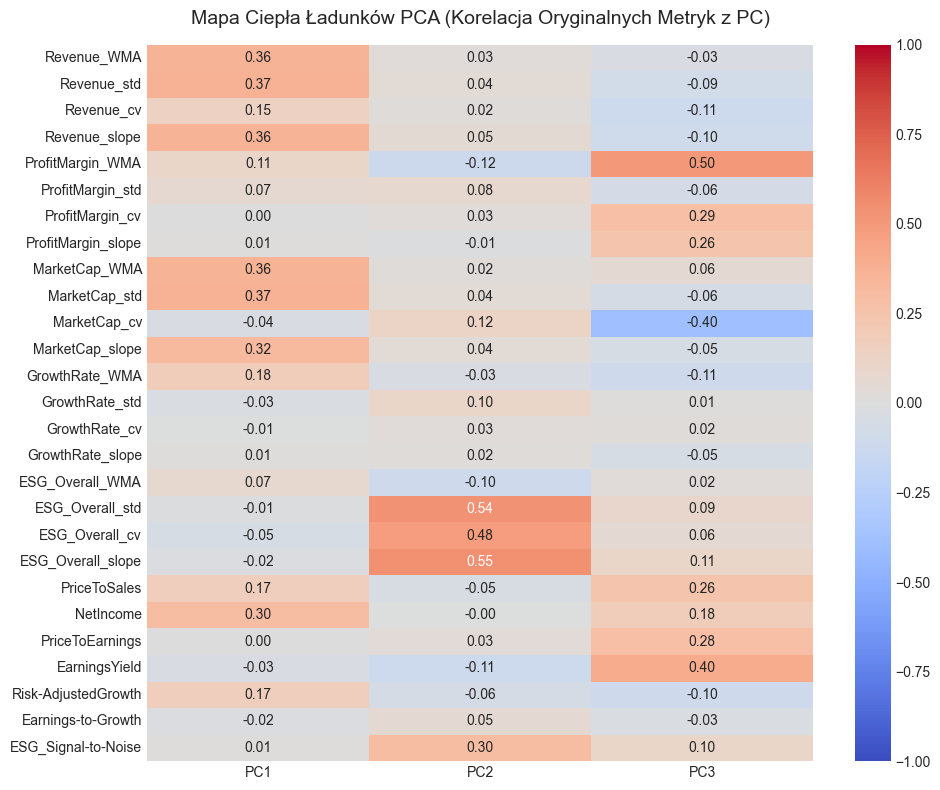

=== CO BUDUJE SKŁADOWĄ PC1? ===
Revenue_std      0.370128
MarketCap_std    0.369149
Revenue_slope    0.364935
MarketCap_WMA    0.364564
Revenue_WMA      0.363283
Name: PC1, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC2? ===
ESG_Overall_slope      0.545916
ESG_Overall_std        0.536472
ESG_Overall_cv         0.479671
ESG_Signal-to-Noise    0.304050
MarketCap_cv           0.122324
Name: PC2, dtype: float64

=== CO BUDUJE SKŁADOWĄ PC3? ===
ProfitMargin_WMA    0.502808
EarningsYield       0.401686
MarketCap_cv        0.395703
ProfitMargin_cv     0.287844
PriceToEarnings     0.282179
Name: PC3, dtype: float64


In [ ]:
num_components_to_analyze = 3 

loadings = pd.DataFrame(
    pca.components_.T[:, :num_components_to_analyze], 
    columns=[f'PC{i+1}' for i in range(num_components_to_analyze)],
    index=X.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Mapa Ciepła Ładunków PCA (Korelacja Oryginalnych Metryk z PC)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T[:, :3],
    columns=['PC1', 'PC2', 'PC3'],
    index=X.columns
)

print("=== CO BUDUJE SKŁADOWĄ PC1? ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC2? ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

print("\n=== CO BUDUJE SKŁADOWĄ PC3? ===")
print(loadings['PC3'].abs().sort_values(ascending=False).head(5))